In [2]:
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [62]:
# The line is a log-pitch axis where one octave spans 0.5.
# A perfect fifth is a FIXED distance on that axis: log2(3/2) octaves.
octave = 0.5
fifth = np.log2(3 / 2) * octave   # ≈ 0.2925  (a constant interval, not a fraction of a gap)

x = [0, 0.5, 1]  # C at the octave boundaries

def new_split(x):
    # How many distinct notes we already have inside one octave [0, 0.5)
    n = len([p for p in x if 0 <= p < octave])
    # Stack one more perfect fifth on the circle of fifths and fold it into the octave
    new_point = (n * fifth) % octave
    # Mirror the note into every octave drawn on the line [0, 1]
    for p in (new_point, new_point + octave):
        if p not in x:
            x.append(p)
    x.sort()
    return x

# Each pass adds the next note in the circle of fifths
# Pass 1
x = new_split(x)

# Pass 2
x = new_split(x)

# Pass 3
x = new_split(x)

# Pass 4
x = new_split(x)

# Pass 5
x = new_split(x)

# Pass 6
x = new_split(x)

# Pass 7
x = new_split(x)


y = []
for i in range(len(x)):
    y.append(1)

print(x)
print(y)


[0, np.float64(0.04736875252404671), np.float64(0.08496250072115619), np.float64(0.16992500144231237), np.float64(0.25488750216346867), np.float64(0.2924812503605781), np.float64(0.37744375108173434), np.float64(0.4624062518028904), 0.5, np.float64(0.5473687525240467), np.float64(0.5849625007211562), np.float64(0.6699250014423124), np.float64(0.7548875021634687), np.float64(0.792481250360578), np.float64(0.8774437510817343), np.float64(0.9624062518028904), 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


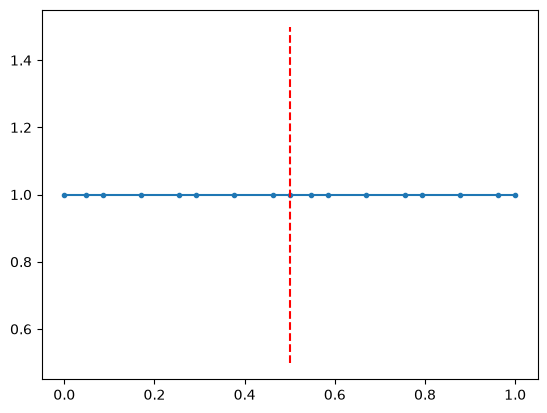

In [63]:
plt.plot(x, y, marker='.')
plt.plot([0.5, 0.5], [0.5, 1.5], color='red', linestyle='--')

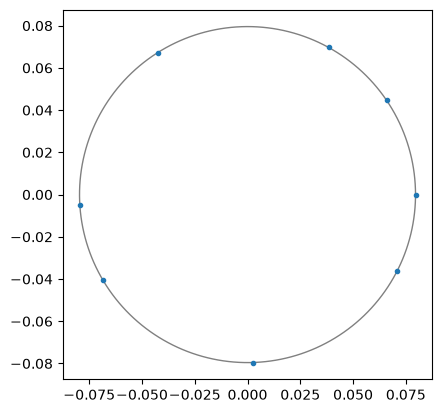

In [64]:
#TODO: Plot the left side of the line (x < 0.5) as a circle, the total length of the circunference is 0.5 and plot the dots as they appear in the line. It should be like having an string with knots in it, but as a circle.

# Points on the left side of the line
left = [p for p in x if p < 0.5]

# The circle's circumference equals 0.5, so its radius is:
circumference = 0.5
radius = circumference / (2 * np.pi)

# Map each point's position along the string (0 -> 0.5) to an angle around the circle
angles = [(p / circumference) * 2 * np.pi for p in left]
cx = [radius * np.cos(a) for a in angles]
cy = [radius * np.sin(a) for a in angles]

fig, ax = plt.subplots()

# Draw the circle (the "string")
theta = np.linspace(0, 2 * np.pi, 400)
ax.plot(radius * np.cos(theta), radius * np.sin(theta), color='gray', linewidth=1)

# Draw the knots
ax.plot(cx, cy, marker='.', linestyle='', color='C0')

ax.set_aspect('equal')
plt.show()


Pentatonic (octave fractions): [np.float64(0.0), np.float64(0.08496250072115619), np.float64(0.16992500144231237), np.float64(0.2924812503605781), np.float64(0.37744375108173434)]


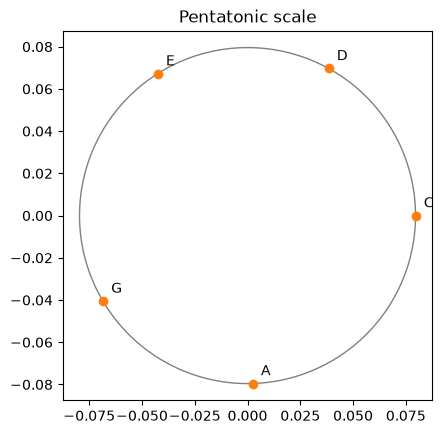

In [54]:
# Pentatonic scale circle
# The pentatonic scale is generated by stacking 5 perfect fifths and
# folding them back into a single octave.

octave = 0.5                      # one octave = 0.5 in this notebook's normalization
fifth = np.log2(3 / 2) * octave   # a perfect fifth expressed in that same space

# Stack 5 fifths (C -> G -> D -> A -> E) and reduce each into one octave
scale_order = [(i * fifth) % octave for i in range(5)]
labels_order = ['C', 'G', 'D', 'A', 'E']

# Sort by pitch so they sit in ascending order around the circle
notes = sorted(zip(scale_order, labels_order))
pentatonic = [p for p, _ in notes]
labels = [l for _, l in notes]
print("Pentatonic (octave fractions):", pentatonic)

# Map onto a circle whose circumference equals one octave
circumference = octave
radius = circumference / (2 * np.pi)

angles = [(p / circumference) * 2 * np.pi for p in pentatonic]
px = [radius * np.cos(a) for a in angles]
py = [radius * np.sin(a) for a in angles]

fig, ax = plt.subplots()

# Draw the circle (the "string")
theta = np.linspace(0, 2 * np.pi, 400)
ax.plot(radius * np.cos(theta), radius * np.sin(theta), color='gray', linewidth=1)

# Draw the knots (the 5 notes) and label them
ax.plot(px, py, marker='o', linestyle='', color='C1')
for xi, yi, name in zip(px, py, labels):
    ax.annotate(name, (xi, yi), textcoords="offset points", xytext=(6, 6))

ax.set_aspect('equal')
ax.set_title('Pentatonic scale')
plt.show()


C major (octave fractions): [np.float64(0.0), np.float64(0.08496250072115619), np.float64(0.16992500144231237), np.float64(0.2075187496394219), np.float64(0.2924812503605781), np.float64(0.37744375108173434), np.float64(0.4624062518028904)]
Order: ['C', 'D', 'E', 'F', 'G', 'A', 'B']


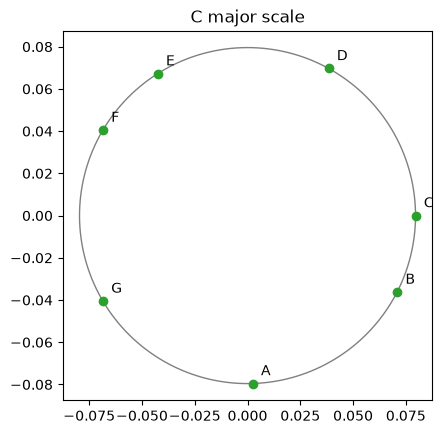

In [55]:
# C major scale circle
# The major (diatonic) scale is 7 notes generated by stacking 7 perfect
# fifths and folding them back into a single octave.

octave = 0.5                      # one octave = 0.5 in this notebook's normalization
fifth = np.log2(3 / 2) * octave   # a perfect fifth expressed in that same space

# Stack 7 fifths (F -> C -> G -> D -> A -> E -> B), starting one fifth below C
scale_order = [((i - 1) * fifth) % octave for i in range(7)]
labels_order = ['F', 'C', 'G', 'D', 'A', 'E', 'B']

# Sort by pitch so they sit in ascending order around the circle
notes = sorted(zip(scale_order, labels_order))
major = [p for p, _ in notes]
labels = [l for _, l in notes]
print("C major (octave fractions):", major)
print("Order:", labels)

# Map onto a circle whose circumference equals one octave
circumference = octave
radius = circumference / (2 * np.pi)

angles = [(p / circumference) * 2 * np.pi for p in major]
px = [radius * np.cos(a) for a in angles]
py = [radius * np.sin(a) for a in angles]

fig, ax = plt.subplots()

# Draw the circle (the "string")
theta = np.linspace(0, 2 * np.pi, 400)
ax.plot(radius * np.cos(theta), radius * np.sin(theta), color='gray', linewidth=1)

# Draw the knots (the 7 notes) and label them
ax.plot(px, py, marker='o', linestyle='', color='C2')
for xi, yi, name in zip(px, py, labels):
    ax.annotate(name, (xi, yi), textcoords="offset points", xytext=(6, 6))

ax.set_aspect('equal')
ax.set_title('C major scale')
plt.show()


In [65]:
# Why log2(3/2): multiplication (ratios) vs addition (positions on a line)
#
# Stacking fifths MULTIPLIES the frequency ratio by 3/2 each time.
# Taking log2 turns that into ADDING log2(3/2) each time -> a straight ruler.

print(f"{'step':>4} | {'ratio (multiply 3/2)':>22} | {'log2(ratio) = position':>24} | {'octaves':>8}")
print("-" * 70)

ratio = 1.0          # start on C (unison, ratio 1)
for step in range(8):
    position = np.log2(ratio)          # distance on the octave-ruler (in octaves)
    reduced = position % 1             # fold back into a single octave [0, 1)
    print(f"{step:>4} | {ratio:>22.5f} | {position:>24.5f} | {reduced:>8.4f}")
    ratio = ratio * (3 / 2)            # go up one more perfect fifth (MULTIPLY)

print()
print("Notice:")
print("  * left column multiplies by 3/2 every row (that's the music)")
print("  * middle column just ADDS log2(3/2) = "
      f"{np.log2(3/2):.5f} every row (that's the ruler)")
print("  * one octave = log2(2) = 1.0, so '% 1' wraps notes back into the octave")


step |   ratio (multiply 3/2) |   log2(ratio) = position |  octaves
----------------------------------------------------------------------
   0 |                1.00000 |                  0.00000 |   0.0000
   1 |                1.50000 |                  0.58496 |   0.5850
   2 |                2.25000 |                  1.16993 |   0.1699
   3 |                3.37500 |                  1.75489 |   0.7549
   4 |                5.06250 |                  2.33985 |   0.3399
   5 |                7.59375 |                  2.92481 |   0.9248
   6 |               11.39062 |                  3.50978 |   0.5098
   7 |               17.08594 |                  4.09474 |   0.0947

Notice:
  * left column multiplies by 3/2 every row (that's the music)
  * middle column just ADDS log2(3/2) = 0.58496 every row (that's the ruler)
  * one octave = log2(2) = 1.0, so '% 1' wraps notes back into the octave
